In [3]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from sklearn.metrics import roc_auc_score, matthews_corrcoef
from os.path import join
import os
import matplotlib.pyplot as plt
import pandas as pd
import re
import statsmodels.api as sm
import seaborn as sns
import warnings
import sys
from sklearn import metrics
sys.path.append("./additional_code/")
from helper_functions import *
CURRENT_DIR = os.getcwd()
print(CURRENT_DIR)

import warnings
warnings.filterwarnings("ignore")

/Users/vahidatabaigi/ESP_Leak_Analysis/notebooks_and_code


# Three-split scenario


Processing ESP...
✓ Loaded: y_test_pred_ESP_I1f_3S.npy and y_test_true_ESP_I1f_3S.npy
✓ Loaded: y_test_pred_ESP_I1e_3S.npy and y_test_true_ESP_I1e_3S.npy
✓ Loaded: y_test_pred_ESP_C1e_3S.npy and y_test_true_ESP_C1e_3S.npy
✓ Loaded: y_test_pred_ESP_C1f_3S.npy and y_test_true_ESP_C1f_3S.npy
✓ Loaded: y_test_pred_ESP_ESP_3S.npy and y_test_true_ESP_ESP_3S.npy
✓ Loaded: y_test_pred_ESP_ESPC2_3S.npy and y_test_true_ESP_ESPC2_3S.npy
✓ Loaded: y_test_pred_ESP_C2_3S.npy and y_test_true_ESP_C2_3S.npy

Processing I1f_3S:
  True labels: [0.000, 1.000], threshold: 0.000
  Predictions: [-0.819, 1.111]
  Binary classes: [0 1], counts: [10181  3663]
  ✓ Success - AUC: 0.937

Processing I1e_3S:
  True labels: [0.000, 1.000], threshold: 0.000
  Predictions: [-0.165, 0.946]
  Binary classes: [0 1], counts: [8459 3662]
  ✓ Success - AUC: 0.565

Processing C1e_3S:
  True labels: [0.000, 1.000], threshold: 0.000
  Predictions: [-0.122, 0.889]
  Binary classes: [0 1], counts: [10177  3662]
  ✓ Success - AUC

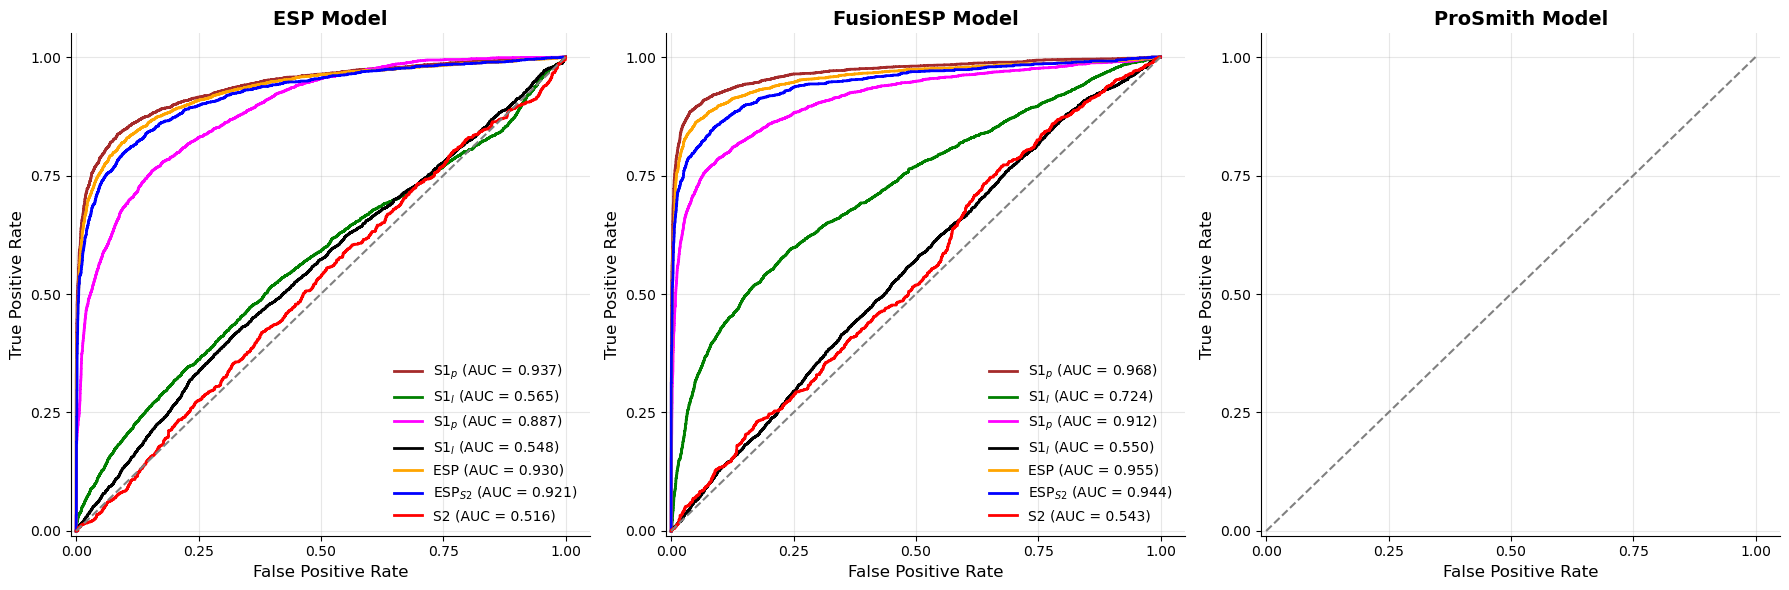


SUMMARY OF RESULTS

ESP:
  S1$_{p}$: AUC = 0.937
  S1$_{l}$: AUC = 0.565
  S1$_{p}$: AUC = 0.887
  S1$_{l}$: AUC = 0.548
  ESP: AUC = 0.930
  ESP$_{S2}$: AUC = 0.921
  S2: AUC = 0.516

FusionESP:
  S1$_{p}$: AUC = 0.968
  S1$_{l}$: AUC = 0.724
  S1$_{p}$: AUC = 0.912
  S1$_{l}$: AUC = 0.550
  ESP: AUC = 0.955
  ESP$_{S2}$: AUC = 0.944
  S2: AUC = 0.543

ProSmith:
  S1$_{p}$: Data not available
  S1$_{l}$: Data not available
  S1$_{p}$: Data not available
  S1$_{l}$: Data not available
  ESP: Data not available
  ESP$_{S2}$: Data not available
  S2: Data not available


In [7]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn import metrics
from os.path import join
import os
import warnings

# Suppress warnings
warnings.filterwarnings("ignore")

# Configuration
CURRENT_DIR = os.getcwd()
DATA_DIR = join(CURRENT_DIR, "..", "data", "training_results_3S")
OUTPUT_PATH = '/Users/vahidatabaigi/Desktop/AUC3S_All_Models.png'

def load_data(file_patterns, model):
    """Load all data files based on patterns for a specific model"""
    data = {}
    for key, filename_pattern in file_patterns.items():
        # Construct actual filename using the model name
        filename = filename_pattern.format(model=model)
        true_filename = filename.replace("y_test_pred", "y_test_true")
        
        try:
            data[f"y_pred_{key}"] = np.load(join(DATA_DIR, filename))
            data[f"y_true_{key}"] = np.load(join(DATA_DIR, true_filename))
            print(f"✓ Loaded: {filename} and {true_filename}")
        except FileNotFoundError as e:
            print(f"✗ Could not load {filename} or {true_filename}: {e}")
    
    return data

def calculate_roc_metrics(y_true, y_pred):
    """Calculate ROC curve and AUC for continuous true labels"""
    # Flatten arrays to ensure 1D
    y_true = y_true.flatten()
    y_pred = y_pred.flatten()
    
    # For continuous true labels, we need to binarize them
    # Common approach: use median or mean as threshold
    threshold = np.median(y_true)
    y_true_binary = (y_true > threshold).astype(int)
    
    print(f"  True labels: [{y_true.min():.3f}, {y_true.max():.3f}], threshold: {threshold:.3f}")
    print(f"  Predictions: [{y_pred.min():.3f}, {y_pred.max():.3f}]")
    print(f"  Binary classes: {np.unique(y_true_binary)}, counts: {np.bincount(y_true_binary)}")
    
    fpr, tpr, _ = metrics.roc_curve(y_true_binary, y_pred)
    roc_auc = metrics.auc(fpr, tpr)
    return fpr, tpr, roc_auc

def plot_roc_curve(fpr, tpr, roc_auc, label, linestyle, color, ax):
    """Plot individual ROC curve"""
    ax.plot(fpr, tpr, label=f'{label} (AUC = {roc_auc:.3f})', 
            linestyle=linestyle, color=color, linewidth=2)

def main():
    # Define models and file patterns
    models = ["ESP", "FusionESP", "ProSmith"]
    model_titles = {
        "ESP": "ESP Model",
        "FusionESP": "FusionESP Model", 
        "ProSmith": "ProSmith Model"
    }
    
    # Define file patterns for all datasets (using format placeholders)
    file_patterns = {
        'I1f_3S': "y_test_pred_{model}_I1f_3S.npy",
        'I1e_3S': "y_test_pred_{model}_I1e_3S.npy",
        'C1e_3S': "y_test_pred_{model}_C1e_3S.npy",
        'C1f_3S': "y_test_pred_{model}_C1f_3S.npy",
        'ESP_3S': "y_test_pred_{model}_ESP_3S.npy",
        'ESPC2_3S': "y_test_pred_{model}_ESPC2_3S.npy",
        'C2_3S': "y_test_pred_{model}_C2_3S.npy",
    }
    
    # Define plotting parameters for all datasets
    plot_configs = [
        ('I1f_3S', 'S1$_{p}$', 'solid', 'brown'),
        ('I1e_3S', 'S1$_{l}$', 'solid', 'green'),
        ('C1f_3S', 'S1$_{p}$', 'solid', 'magenta'),
        ('C1e_3S', 'S1$_{l}$', 'solid', 'black'),
        ('ESP_3S', 'ESP', 'solid', 'orange'),
        ('ESPC2_3S', 'ESP$_{S2}$', 'solid', 'blue'),
        ('C2_3S', 'S2', 'solid', 'red'),
    ]
    
    # Create a single figure with subplots
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    plt.rcParams.update({'font.size': 10})
    
    # Store results for all models
    all_results = {}
    
    # Process each model
    for i, model in enumerate(models):
        print(f"\n{'='*50}")
        print(f"Processing {model}...")
        print(f"{'='*50}")
        
        # Load data for current model
        data = load_data(file_patterns, model)
        
        # Calculate ROC metrics for all datasets
        roc_data = {}
        successful_datasets = []
        
        for key in file_patterns.keys():
            y_true_key = f"y_true_{key}"
            y_pred_key = f"y_pred_{key}"
            
            if y_true_key in data and y_pred_key in data:
                y_true = data[y_true_key]
                y_pred = data[y_pred_key]
                
                print(f"\nProcessing {key}:")
                
                try:
                    fpr, tpr, roc_auc = calculate_roc_metrics(y_true, y_pred)
                    roc_data[key] = {'fpr': fpr, 'tpr': tpr, 'auc': roc_auc}
                    successful_datasets.append(key)
                    print(f"  ✓ Success - AUC: {roc_auc:.3f}")
                except Exception as e:
                    print(f"  ✗ Error calculating ROC for {key}: {e}")
            else:
                print(f"  ✗ Missing data for {key}")
        
        print(f"\nSuccessfully processed {len(successful_datasets)} out of {len(file_patterns)} datasets for {model}")
        all_results[model] = roc_data
        
        # Get the current subplot axis
        ax = axes[i]
        
        # Plot ROC curves for available datasets
        print(f"\nPlotting ROC curves for {model}...")
        for data_key, label, linestyle, color in plot_configs:
            if data_key in roc_data:
                plot_roc_curve(
                    roc_data[data_key]['fpr'], 
                    roc_data[data_key]['tpr'], 
                    roc_data[data_key]['auc'], 
                    label, linestyle, color, ax
                )
                print(f"  ✓ Plotted: {label}")
            else:
                print(f"  ✗ Skipped: {label} (data not available)")
        
        # Configure subplot appearance
        ax.locator_params(axis="y", nbins=5)
        ax.locator_params(axis="x", nbins=5)
        ax.tick_params(axis='x', labelsize=10)
        ax.tick_params(axis='y', labelsize=10)
        
        # Remove top and right spines
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        
        # Add diagonal reference line (without legend label)
        ax.plot([0, 1], [0, 1], '--', color='gray', linewidth=1.5)
        
        # Set limits and labels
        ax.set_xlim([-0.01, 1.05])
        ax.set_ylim([-0.01, 1.05])
        ax.set_ylabel('True Positive Rate', fontsize=12)
        ax.set_xlabel('False Positive Rate', fontsize=12)
        ax.set_title(model_titles[model], fontsize=14, fontweight='bold')
        
        # Add legend to each subplot
        ax.legend(loc='lower right', fontsize=10, frameon=False)
        
        # Add grid for better readability
        ax.grid(True, alpha=0.3)
    
    # Adjust layout and save
    plt.tight_layout()
    # plt.savefig(OUTPUT_PATH, dpi=600, bbox_inches='tight')
    print(f"\n✓ All plots saved to: {OUTPUT_PATH}")
    plt.show()
    
    # Print summary of results
    print(f"\n{'='*60}")
    print("SUMMARY OF RESULTS")
    print(f"{'='*60}")
    for model in models:
        print(f"\n{model}:")
        if model in all_results:
            for data_key, label, _, _ in plot_configs:
                if data_key in all_results[model]:
                    auc = all_results[model][data_key]['auc']
                    print(f"  {label}: AUC = {auc:.3f}")
                else:
                    print(f"  {label}: Data not available")
        else:
            print(f"  No results available")

if __name__ == "__main__":
    main()

In [16]:
datasets = [
    ('ECFP ESP', test_y_esm1b_ts_ecfp_ESP_3S, y_test_pred_esm1b_ts_ecfp_ESP_3S),
    ('GNN ESP', test_y_esm1b_ts_gnn_ESP_3S, y_test_pred_esm1b_ts_gnn_ESP_3S),
    ('ECFP S1l', test_y_esm1b_ts_ecfp_C1e_3S, y_test_pred_esm1b_ts_ecfp_C1e_3S),
    ('GNN S1l', test_y_esm1b_ts_gnn_C1e_3S, y_test_pred_esm1b_ts_gnn_C1e_3S),
    ('ECFP S1p', test_y_esm1b_ts_ecfp_C1f_3S, y_test_pred_esm1b_ts_ecfp_C1f_3S),
    ('GNN S1p', test_y_esm1b_ts_gnn_C1f_3S, y_test_pred_esm1b_ts_gnn_C1f_3S),
    ('ECFP I1l', test_y_esm1b_ts_ecfp_I1e_3S, y_test_pred_esm1b_ts_ecfp_I1e_3S),
    ('GNN I1l', test_y_esm1b_ts_gnn_I1e_3S, y_test_pred_esm1b_ts_gnn_I1e_3S),
    ('ECFP I1p', test_y_esm1b_ts_ecfp_I1f_3S, y_test_pred_esm1b_ts_ecfp_I1f_3S),
    ('GNN I1p', test_y_esm1b_ts_gnn_I1f_3S, y_test_pred_esm1b_ts_gnn_I1f_3S),
    ('ECFP S2', test_y_esm1b_ts_ecfp_C2_3S, y_test_pred_esm1b_ts_ecfp_C2_3S),
    ('ECFP ESPS2', test_y_esm1b_ts_ecfp_ESPC2_3S, y_test_pred_esm1b_ts_ecfp_ESPC2_3S),
    ('GNN S2', test_y_esm1b_ts_gnn_C2_3S, y_test_pred_esm1b_ts_gnn_C2_3S),
    ('GNN ESPS2', test_y_esm1b_ts_gnn_ESPC2_3S, y_test_pred_esm1b_ts_gnn_ESPC2_3S)
]


results = []
for name, y_true, y_pred in datasets:
    mcc, accuracy= calculate_metrics(y_true, y_pred)
    results.append((name, mcc, accuracy))

# Create and display the results table
print(f"{'Model':<20} {'MCC':<10} {'Accuracy':<10}")
print("=" * 50)
for name, mcc, accuracy in results:
    print(f"{name:<20} {mcc:.4f}    {accuracy:.4f}")


Model                MCC        Accuracy  
ECFP ESP             0.7065    0.8840
GNN ESP              0.7113    0.8867
ECFP S1l             0.0952    0.5824
GNN S1l              0.0302    0.4073
ECFP S1p             0.5737    0.8080
GNN S1p              0.4606    0.6939
ECFP I1l             0.1443    0.5255
GNN I1l              0.1038    0.5660
ECFP I1p             0.7503    0.9018
GNN I1p              0.7474    0.9020
ECFP S2              0.0236    0.4404
ECFP ESPS2           0.6748    0.8728
GNN S2               0.0220    0.5453
GNN ESPS2            0.6909    0.8794


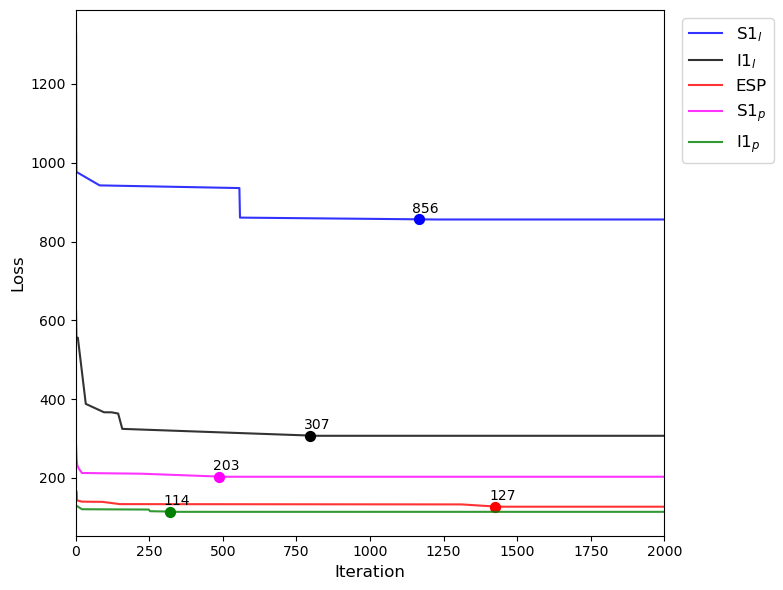

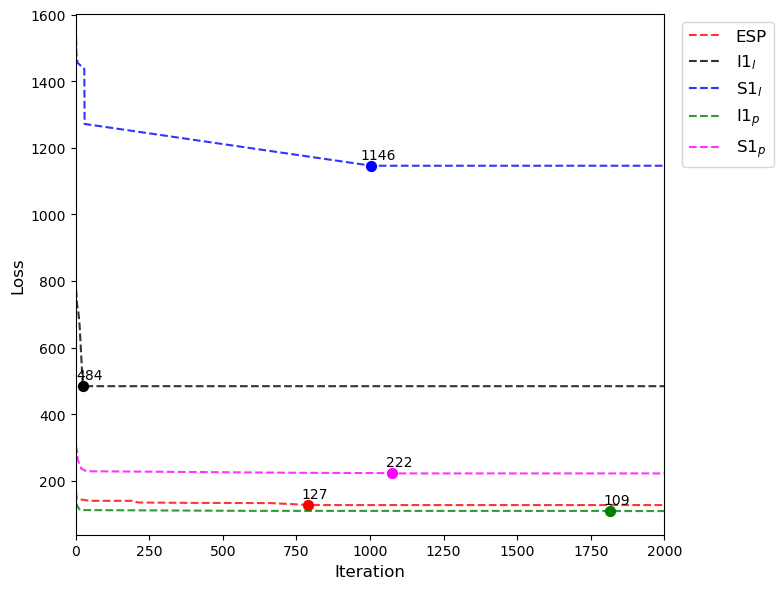

In [17]:
log_directory = '/Users/vahidatabaigi/SIP/ESP_HardSplits/data/Reports/hyperOp_report'
log_files = [f for f in os.listdir(log_directory) if f.endswith('.log')]

color_map = {'ESP': 'red', 'S1$_{l}$': 'blue', 'S1$_{p}$': 'magenta', 'I1$_{l}$': 'black', 'I1$_{p}$': 'green'}

plotting_loss("ECFP", experiment="1D", log_directory=log_directory, color_map=color_map, split_number=3)
plotting_loss("PreGNN", experiment="1D", log_directory=log_directory, color_map=color_map, split_number=3)

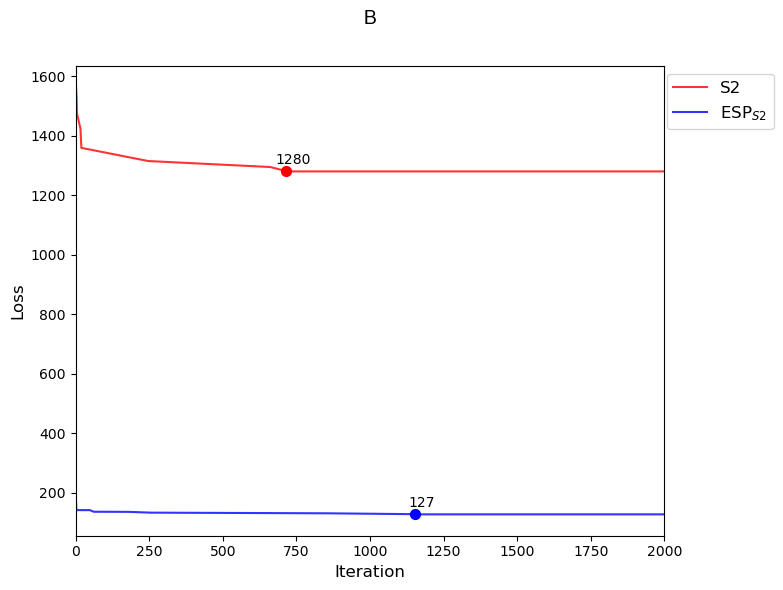

In [18]:
log_directory = '/Users/vahidatabaigi/SIP/ESP_HardSplits/data/Reports/hyperOp_report'
log_files = [f for f in os.listdir(log_directory) if f.endswith('.log')]

color_map = {'ESP$_{S2}$': 'blue', 'S2': 'red'}
plotting_loss("ECFP", experiment="2D", log_directory=log_directory, color_map=color_map, split_number=3,title="B")

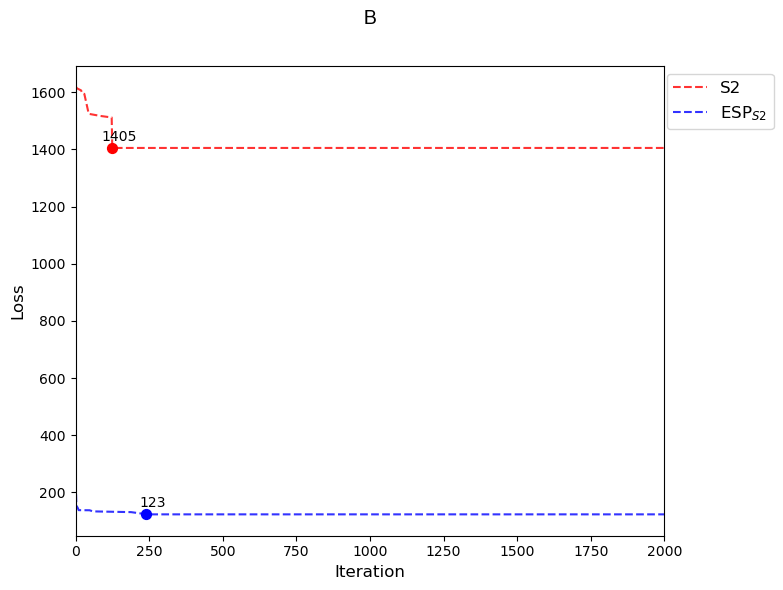

In [19]:
log_directory = '/Users/vahidatabaigi/SIP/ESP_HardSplits/data/Reports/hyperOp_report'
log_files = [f for f in os.listdir(log_directory) if f.endswith('.log')]

color_map = {'ESP$_{S2}$': 'blue', 'S2': 'red'}

plotting_loss("PreGNN", experiment="2D", log_directory=log_directory, color_map=color_map, split_number=3,title="B")

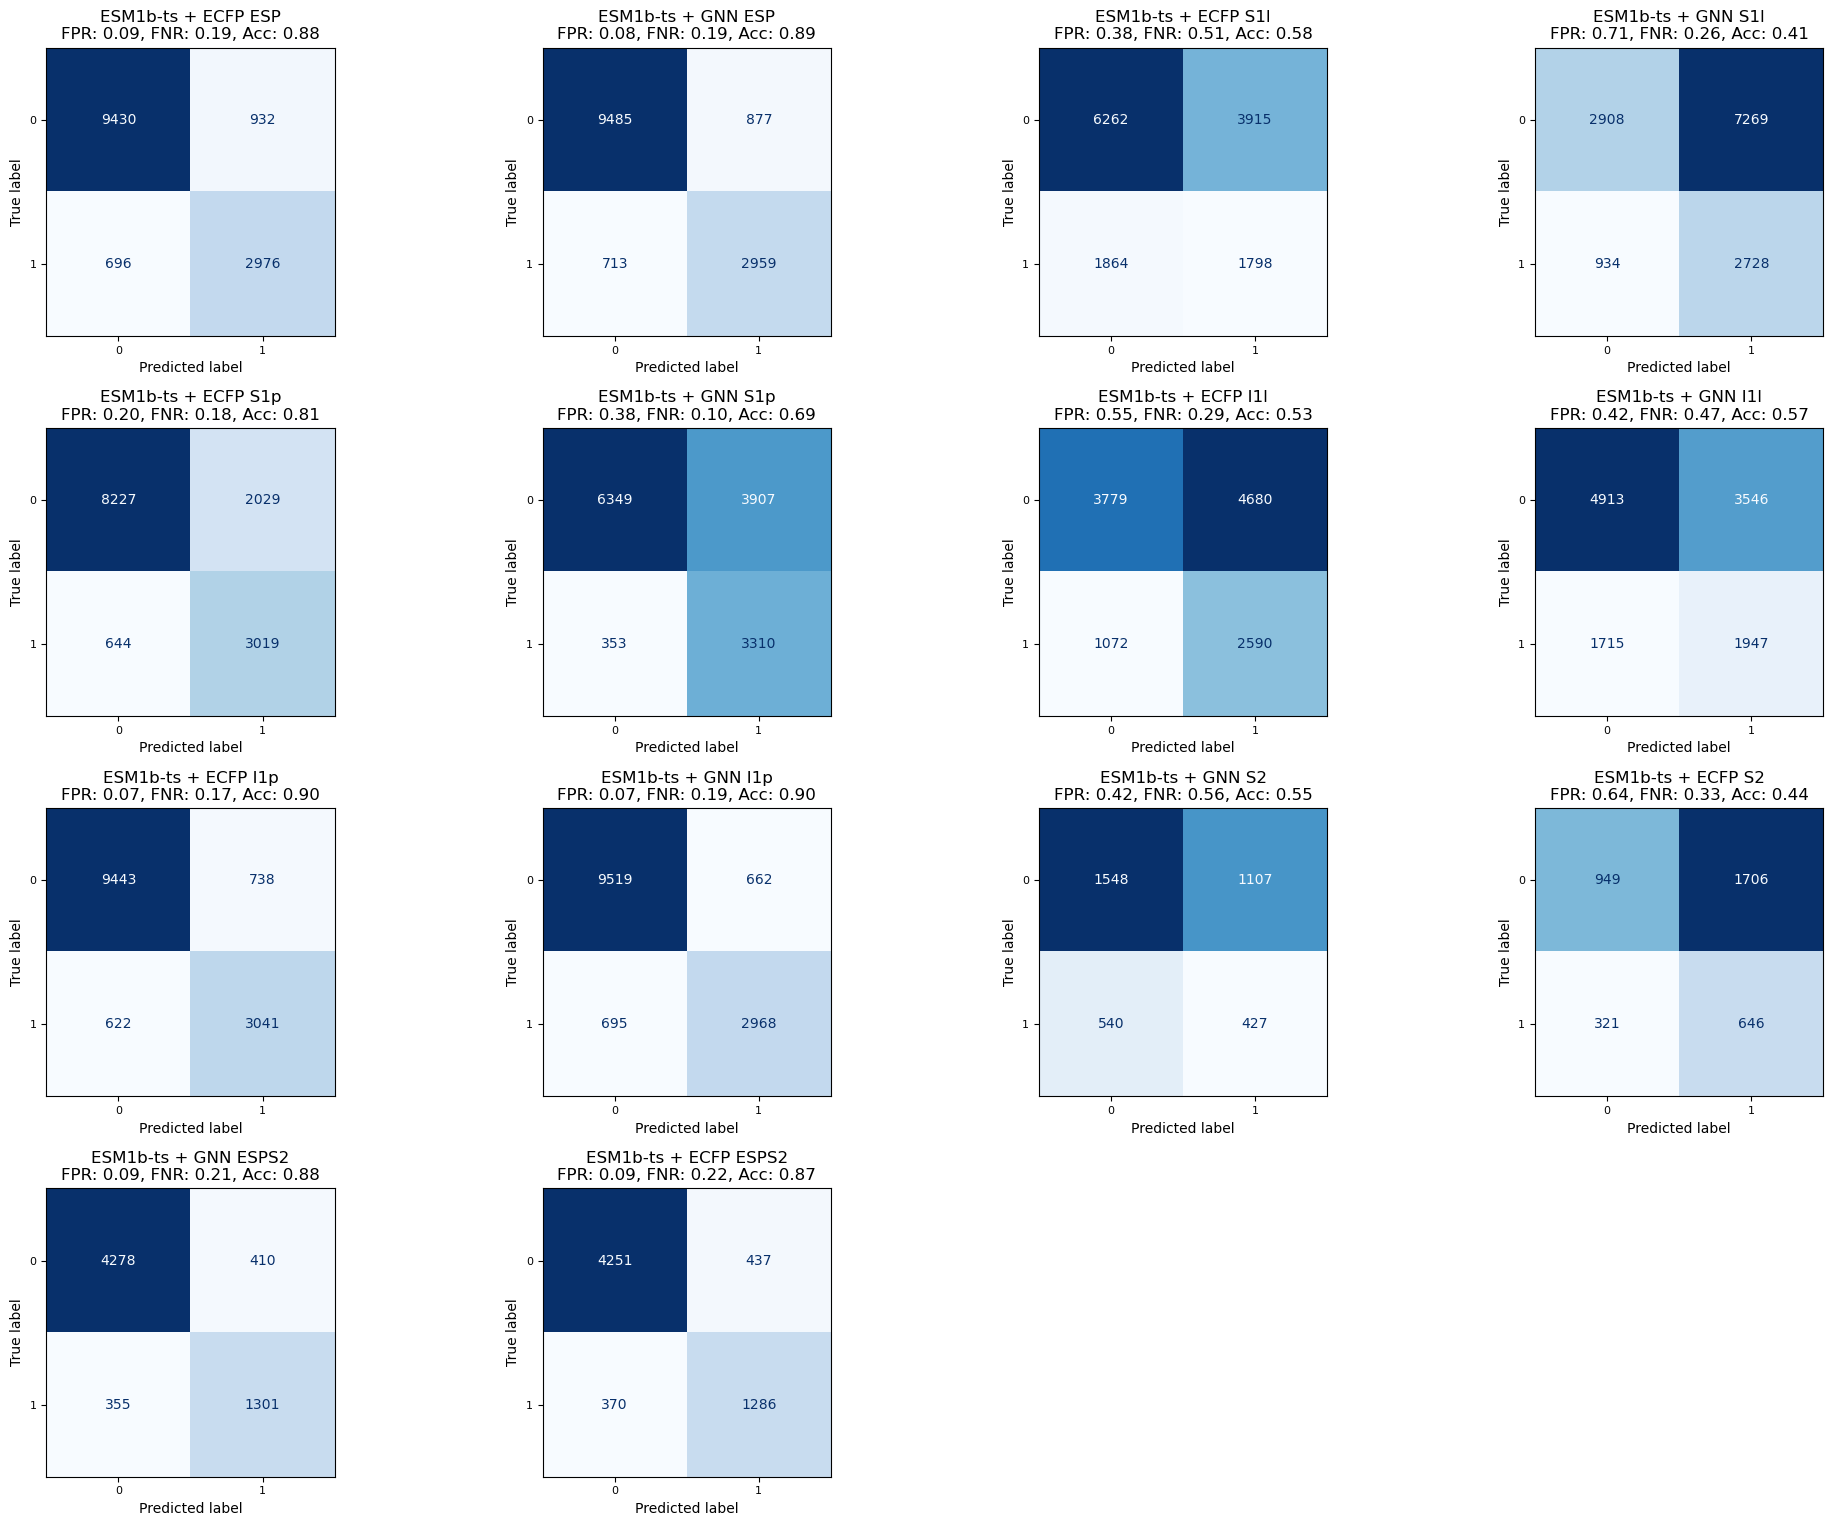

In [20]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

datasets = [
    ('ECFP ESP', test_y_esm1b_ts_ecfp_ESP_3S, y_test_pred_esm1b_ts_ecfp_ESP_3S),
    ('GNN ESP', test_y_esm1b_ts_gnn_ESP_3S, y_test_pred_esm1b_ts_gnn_ESP_3S),
    ('ECFP S1l', test_y_esm1b_ts_ecfp_C1e_3S, y_test_pred_esm1b_ts_ecfp_C1e_3S),
    ('GNN S1l', test_y_esm1b_ts_gnn_C1e_3S, y_test_pred_esm1b_ts_gnn_C1e_3S),
    ('ECFP S1p', test_y_esm1b_ts_ecfp_C1f_3S, y_test_pred_esm1b_ts_ecfp_C1f_3S),
    ('GNN S1p', test_y_esm1b_ts_gnn_C1f_3S, y_test_pred_esm1b_ts_gnn_C1f_3S),
    ('ECFP I1l', test_y_esm1b_ts_ecfp_I1e_3S, y_test_pred_esm1b_ts_ecfp_I1e_3S),
    ('GNN I1l', test_y_esm1b_ts_gnn_I1e_3S, y_test_pred_esm1b_ts_gnn_I1e_3S),
    ('ECFP I1p', test_y_esm1b_ts_ecfp_I1f_3S, y_test_pred_esm1b_ts_ecfp_I1f_3S),
    ('GNN I1p', test_y_esm1b_ts_gnn_I1f_3S, y_test_pred_esm1b_ts_gnn_I1f_3S),
    ('GNN S2', test_y_esm1b_ts_gnn_C2_3S, y_test_pred_esm1b_ts_gnn_C2_3S),
    ('ECFP S2', test_y_esm1b_ts_ecfp_C2_3S, y_test_pred_esm1b_ts_ecfp_C2_3S),
    ('GNN ESPS2', test_y_esm1b_ts_gnn_ESPC2_3S, y_test_pred_esm1b_ts_gnn_ESPC2_3S),
    ('ECFP ESPS2', test_y_esm1b_ts_ecfp_ESPC2_3S, y_test_pred_esm1b_ts_ecfp_ESPC2_3S)
]

n_rows = 4
n_cols = 4
fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 16))
#fig.suptitle('Confusion Matrices for Different Models (3 splits)', fontsize=14)
for i, (name, y_true, y_pred) in enumerate(datasets):
    fpr, fnr,accuracy, cm = calculate_fpr_fnr_accuracy(y_true, y_pred)
    row, col = divmod(i, n_cols)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(ax=axes[row, col], cmap='Blues', colorbar=False)
    axes[row, col].set_title(f"ESM1b-ts + {name}\nFPR: {fpr:.2f}, FNR: {fnr:.2f}, Acc: {accuracy:.2f}", fontsize=12)
    for text in axes[row, col].texts:
        text.set_fontsize(10)
    axes[row, col].tick_params(axis='both', which='major', labelsize=8)
    axes[row, col].set_xlabel(axes[row, col].get_xlabel(), fontsize=10)
    axes[row, col].set_ylabel(axes[row, col].get_ylabel(), fontsize=10)
for j in range(len(datasets), n_rows * n_cols):
    fig.delaxes(axes.flat[j])
plt.subplots_adjust(hspace=0.9, wspace=0.1)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig('/Users/vahidatabaigi/Desktop/Thesis/thesis-template/Figures/CM3S.png', dpi=600, bbox_inches='tight')
plt.show()

# Similarity-based leakage calculation

### two-split ESM1Bts+ECFP

In [6]:
df_results_ecfp = pd.read_csv(join("..", "data", "2splits", "Similarity_leakage_ESM1bts_ECFP_2S.csv"))
change_name = {'ESP':'ESP','ESPC2': 'ESPS2', 'I1f': 'I1p','I1e':'I1l', 'C1f':'S1p','C1e':'S1l', 'C2':'S2'}
df_results_ecfp['Split method'] = df_results_ecfp['Split method'].map(change_name)

In [7]:
df_avg_results_ecfp = df_results_ecfp.groupby('Split method').mean().reset_index().drop(columns=["Fold_number"])
AUROC = {"ESP": 0.957,"ESPS2":0.942, "I1p": 0.955,"S1p": 0.922, "I1l": 0.703,  "S1l": 0.547, "S2":0.543}
df_avg_results_ecfp['AUROC'] = df_avg_results_ecfp['Split method'].map(AUROC)

In [9]:
df_avg_results_ecfp["train_test_TSL"]=df_avg_results_ecfp["train_test_smiles_leakage"]+ df_avg_results_ecfp["train_test_protein_leakage"]
df_avg_results_ecfp["train_val_TSL"]=df_avg_results_ecfp["train_val_smiles_leakage"]+ df_avg_results_ecfp["train_val_protein_leakage"]
df_avg_results_ecfp["test_val_TSL"]=df_avg_results_ecfp["test_val_smiles_leakage"]+ df_avg_results_ecfp["test_val_protein_leakage"]

df_avg_results_ecfp = df_avg_results_ecfp[["Split method","train_val_smiles_leakage", "train_val_protein_leakage","train_val_TSL", "train_test_smiles_leakage", "train_test_protein_leakage","train_test_TSL", 
                                  
                                 "test_val_smiles_leakage", "test_val_protein_leakage","test_val_TSL", "AUROC"]]
df_avg_results_ecfp.round(3)
desired_order = ["ESP", "ESPS2", "I1p", "S1p", "I1l", "S1l", "S2"]
df_transposed_ecfp = df_avg_results_ecfp.set_index('Split method').T
df_transposed_ecfp = df_transposed_ecfp[desired_order]
df_transposed_ecfp = df_transposed_ecfp.round(3)
df_transposed_ecfp


Split method,ESP,ESPS2,I1p,S1p,I1l,S1l,S2
train_val_smiles_leakage,0.200,0.204,0.202,0.202,0.216,0.254,0.256
train_val_protein_leakage,0.118,0.128,0.120,0.132,0.190,0.192,0.218
train_val_TSL,0.318,0.332,0.322,0.334,0.406,0.446,0.474
train_test_smiles_leakage,0.260,0.254,0.260,0.260,0.198,0.096,0.080
train_test_protein_leakage,0.100,0.102,0.110,0.040,0.126,0.114,0.020
train_test_TSL,0.360,0.356,0.370,0.300,0.324,0.210,0.100
test_val_smiles_leakage,0.066,0.062,0.066,0.062,0.050,0.024,0.022
test_val_protein_leakage,0.022,0.028,0.030,0.010,0.026,0.024,0.004
test_val_TSL,0.088,0.090,0.096,0.072,0.076,0.048,0.026
AUROC,0.957,0.942,0.955,0.922,0.703,0.547,0.543


In [10]:
numeric_columns = df_avg_results_ecfp.select_dtypes(include=['float64', 'int64'])
correlation_with_auc = numeric_columns.corr()['AUROC']
correlation_with_auc.round(3)

train_val_smiles_leakage     -0.962
train_val_protein_leakage    -0.971
train_val_TSL                -0.992
train_test_smiles_leakage     0.978
train_test_protein_leakage    0.184
train_test_TSL                0.866
test_val_smiles_leakage       0.977
test_val_protein_leakage      0.382
test_val_TSL                  0.895
AUROC                         1.000
Name: AUROC, dtype: float64

### Two-split ESM1Bts+PreGNN

In [11]:
df_results_gnn = pd.read_csv(join("..", "data", "2splits", "Similarity_leakage_ESM1bts_PreGNN_2S.csv"))
change_name = {'ESP':'ESP','ESPC2': 'ESPS2', 'I1f': 'I1p','I1e':'I1l', 'C1f':'S1p','C1e':'S1l', 'C2':'S2'}
df_results_gnn['Split method'] = df_results_gnn['Split method'].map(change_name)

In [15]:
df_avg_results_gnn = df_results_gnn.groupby('Split method').mean().reset_index().drop(columns=["Fold_number"])
AUROC = {"ESP": 0.959,"ESPS2":0.941, "I1p": 0.959,"S1p": 0.923, "I1l": 0.581,  "S1l": 0.510, "S2":0.509}
df_avg_results_gnn['AUROC'] = df_avg_results_gnn['Split method'].map(AUROC)

df_avg_results_gnn["train_test_TSL"]=df_avg_results_gnn["train_test_smiles_leakage"]+ df_avg_results_gnn["train_test_protein_leakage"]
df_avg_results_gnn["train_val_TSL"]=df_avg_results_gnn["train_val_smiles_leakage"]+ df_avg_results_gnn["train_val_protein_leakage"]
df_avg_results_gnn["test_val_TSL"]=df_avg_results_gnn["test_val_smiles_leakage"]+ df_avg_results_gnn["test_val_protein_leakage"]

df_avg_results_gnn = df_avg_results_gnn[["Split method", "train_val_smiles_leakage", "train_val_protein_leakage","train_val_TSL", "train_test_smiles_leakage", "train_test_protein_leakage","train_test_TSL", 
                                  
                                 "test_val_smiles_leakage", "test_val_protein_leakage","test_val_TSL", "AUROC"]]
desired_order = ["ESP", "ESPS2", "I1p", "S1p", "I1l", "S1l", "S2"]
df_transposed_gnn = df_avg_results_gnn.set_index('Split method').T
df_transposed_gnn = df_transposed_gnn[desired_order]
df_transposed_gnn = df_transposed_gnn.round(3)
df_transposed_gnn

Split method,ESP,ESPS2,I1p,S1p,I1l,S1l,S2
train_val_smiles_leakage,0.201,0.206,0.203,0.203,0.218,0.254,0.259
train_val_protein_leakage,0.118,0.127,0.120,0.132,0.193,0.192,0.216
train_val_TSL,0.319,0.333,0.323,0.335,0.411,0.446,0.475
train_test_smiles_leakage,0.262,0.255,0.260,0.259,0.196,0.096,0.081
train_test_protein_leakage,0.099,0.104,0.110,0.041,0.126,0.114,0.021
train_test_TSL,0.361,0.359,0.370,0.300,0.322,0.209,0.102
test_val_smiles_leakage,0.066,0.063,0.065,0.065,0.049,0.024,0.020
test_val_protein_leakage,0.025,0.026,0.028,0.010,0.027,0.024,0.005
test_val_TSL,0.090,0.089,0.093,0.075,0.076,0.048,0.025
AUROC,0.959,0.941,0.959,0.923,0.581,0.510,0.509


In [16]:
numeric_columns = df_avg_results_gnn.select_dtypes(include=['float64', 'int64'])
correlation_with_auc = numeric_columns.corr()['AUROC']
correlation_with_auc.round(3)

train_val_smiles_leakage     -0.909
train_val_protein_leakage    -0.985
train_val_TSL                -0.980
train_test_smiles_leakage     0.935
train_test_protein_leakage    0.099
train_test_TSL                0.800
test_val_smiles_leakage       0.935
test_val_protein_leakage      0.270
test_val_TSL                  0.845
AUROC                         1.000
Name: AUROC, dtype: float64

### Three-split

In [18]:
df_results_3S = pd.read_csv(join("..", "data", "3splits", "Similarity_leakage_3S.csv"))
change_name = {'ESP':'ESP','ESPC2': 'ESPS2', 'I1f': 'I1p','I1e':'I1l', 'C1f':'S1p','C1e':'S1l', 'C2':'S2'}
df_results_3S['Split method'] = df_results_3S['Split method'].map(change_name)

In [19]:

AUROC_ECFP = {"ESP": 0.929, "I1p": 0.947, "I1l": 0.616, "S1p": 0.903, "S1l": 0.564, "S2":0.531, "ESPS2":0.920}
AUROC_PreGNN = {"ESP": 0.930, "I1p": 0.937, "I1l": 0.565, "S1p": 0.887, "S1l": 0.548, "S2":0.516, "ESPS2":0.921}
df_results_3S['AUROC_ECFP'] = df_results_3S['Split method'].map(AUROC_ECFP)
df_results_3S['AUROC_PreGNN'] = df_results_3S['Split method'].map(AUROC_PreGNN)
df_results_3S

df_results_3S["train_test_TSL"]=df_results_3S["train_test_smiles_leakage"]+ df_results_3S["train_test_protein_leakage"]
df_results_3S["train_val_TSL"]=df_results_3S["train_val_smiles_leakage"]+ df_results_3S["train_val_protein_leakage"]
df_results_3S["test_val_TSL"]=df_results_3S["test_val_smiles_leakage"]+ df_results_3S["test_val_protein_leakage"]

df_results_3S = df_results_3S[["Split method","train_val_smiles_leakage", "train_val_protein_leakage","train_val_TSL", "train_test_smiles_leakage", "train_test_protein_leakage","train_test_TSL", 
                                  
                                 "test_val_smiles_leakage", "test_val_protein_leakage","test_val_TSL", "AUROC_ECFP", "AUROC_PreGNN"]]

desired_order = ["ESP", "ESPS2", "I1p", "S1p", "I1l", "S1l", "S2"]
df_transposed_3S = df_results_3S.set_index('Split method').T
df_transposed_3S = df_transposed_3S[desired_order]
df_transposed_3S = df_transposed_3S.round(3)
df_transposed_3S

Split method,ESP,ESPS2,I1p,S1p,I1l,S1l,S2
train_val_smiles_leakage,0.142,0.141,0.141,0.144,0.128,0.062,0.023
train_val_protein_leakage,0.052,0.056,0.053,0.022,0.070,0.058,0.009
train_val_TSL,0.194,0.197,0.194,0.166,0.198,0.120,0.032
train_test_smiles_leakage,0.284,0.285,0.284,0.278,0.249,0.136,0.067
train_test_protein_leakage,0.100,0.112,0.133,0.044,0.089,0.112,0.015
train_test_TSL,0.384,0.397,0.417,0.322,0.338,0.248,0.082
test_val_smiles_leakage,0.042,0.042,0.042,0.041,0.029,0.018,0.004
test_val_protein_leakage,0.015,0.015,0.028,0.007,0.016,0.012,0.002
test_val_TSL,0.057,0.057,0.070,0.048,0.045,0.030,0.006
AUROC_ECFP,0.929,0.920,0.947,0.903,0.616,0.564,0.531


In [20]:
numeric_columns = df_results_3S.select_dtypes(include=['float64', 'int64'])
correlation_with_auc = numeric_columns.corr()['AUROC_ECFP']
correlation_with_auc.round(3)

train_val_smiles_leakage      0.850
train_val_protein_leakage     0.127
train_val_TSL                 0.713
train_test_smiles_leakage     0.869
train_test_protein_leakage    0.415
train_test_TSL                0.810
test_val_smiles_leakage       0.930
test_val_protein_leakage      0.517
test_val_TSL                  0.865
AUROC_ECFP                    1.000
AUROC_PreGNN                  0.997
Name: AUROC_ECFP, dtype: float64

In [21]:
numeric_columns = df_results_3S.select_dtypes(include=['float64', 'int64'])
correlation_with_auc = numeric_columns.corr()['AUROC_PreGNN']
correlation_with_auc.round(3)

train_val_smiles_leakage      0.815
train_val_protein_leakage     0.099
train_val_TSL                 0.675
train_test_smiles_leakage     0.837
train_test_protein_leakage    0.409
train_test_TSL                0.783
test_val_smiles_leakage       0.908
test_val_protein_leakage      0.494
test_val_TSL                  0.840
AUROC_ECFP                    0.997
AUROC_PreGNN                  1.000
Name: AUROC_PreGNN, dtype: float64